# Experiment 8: Clustering Human Activity Recognition Data

**Sri Sivasubramaniya Nadar College of Engineering, Chennai**  
**ICS1512 – Machine Learning Algorithms Laboratory**  
**M.Tech (Integrated) Computer Science & Engineering – Semester V**

### Experiment 8
**Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering**

### Aim
To implement K-Means, DBSCAN and Hierarchical Agglomerative Clustering on the Human Activity Recognition dataset and compare the clusters using clustering measures and visualizations.



## 1. Upload and extract the dataset


In [1]:
from google.colab import files
import os
import zipfile

print("Choose the Human Activity Recognition ZIP file.")
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file was uploaded.")

uploaded_zip = next(
    (name for name in uploaded if name.lower().endswith(".zip")),
    None
)

if uploaded_zip is None:
    raise ValueError("Please upload a .zip file.")

print("\nUploaded:", uploaded_zip)

# Main extraction folder
EXTRACT_ROOT = "/content/har_extracted"
os.makedirs(EXTRACT_ROOT, exist_ok=True)

# Extract the uploaded ZIP
with zipfile.ZipFile(uploaded_zip, "r") as z:
    z.extractall(EXTRACT_ROOT)

print("First ZIP extracted.")

# Some versions of the downloaded dataset contain a second ZIP
# inside the first ZIP. Extract every nested ZIP we find.
processed_zips = set()

while True:
    nested_zips = []

    for root, dirs, filenames in os.walk(EXTRACT_ROOT):
        for filename in filenames:
            if filename.lower().endswith(".zip"):
                path = os.path.join(root, filename)
                if path not in processed_zips:
                    nested_zips.append(path)

    if not nested_zips:
        break

    for nested_zip in nested_zips:
        print("Extracting nested ZIP:", os.path.basename(nested_zip))

        with zipfile.ZipFile(nested_zip, "r") as z:
            target = os.path.splitext(nested_zip)[0]
            os.makedirs(target, exist_ok=True)
            z.extractall(target)

        processed_zips.add(nested_zip)

print("Extraction completed.")

Choose the Human Activity Recognition ZIP file.


Saving human+activity+recognition+using+smartphones.zip to human+activity+recognition+using+smartphones.zip

Uploaded: human+activity+recognition+using+smartphones.zip
First ZIP extracted.
Extracting nested ZIP: UCI HAR Dataset.zip
Extraction completed.


In [2]:
# Find the actual UCI HAR Dataset directory.

base = None

for root, dirs, filenames in os.walk(EXTRACT_ROOT):
    required = {"features.txt", "activity_labels.txt"}

    if required.issubset(set(filenames)):
        train_ok = os.path.isdir(os.path.join(root, "train"))
        test_ok = os.path.isdir(os.path.join(root, "test"))

        if train_ok and test_ok:
            base = root
            break

if base is None:
    print("Folders found under extraction directory:")
    for root, dirs, filenames in os.walk(EXTRACT_ROOT):
        level = root.replace(EXTRACT_ROOT, "").count(os.sep)
        if level <= 3:
            print("  " * level + os.path.basename(root) + "/")

    raise FileNotFoundError(
        "\nUCI HAR Dataset was not found. "
        "Please check that the uploaded ZIP is the Human Activity Recognition dataset."
    )

print("Dataset folder found:")
print(base)

print("\nDataset files:")
for item in sorted(os.listdir(base)):
    print(" -", item)

Dataset folder found:
/content/har_extracted/UCI HAR Dataset/UCI HAR Dataset

Dataset files:
 - .DS_Store
 - README.txt
 - activity_labels.txt
 - features.txt
 - features_info.txt
 - test
 - train


## 2. Import required libraries

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Human Activity Recognition dataset



In [4]:
feature_file = os.path.join(base, "features.txt")

features = pd.read_csv(
    feature_file,
    sep=r"\s+",
    header=None,
    names=["id", "feature"]
)

features["feature"] = (
    features["feature"]
    .str.replace(r"\(\)", "", regex=True)
    .str.replace("-", "_", regex=False)
    .str.replace(",", "_", regex=False)
)

# Make feature names unique because the original feature list
# contains a few repeated names.
seen = {}
feature_names = []

for name in features["feature"]:
    count = seen.get(name, 0)

    if count == 0:
        new_name = name
    else:
        new_name = f"{name}_{count}"

    feature_names.append(new_name)
    seen[name] = count + 1

print("Number of features:", len(feature_names))

Number of features: 561


In [5]:
activity_labels = pd.read_csv(
    os.path.join(base, "activity_labels.txt"),
    sep=r"\s+",
    header=None,
    names=["activity_id", "activity"]
)

def load_split(split):
    x_path = os.path.join(base, split, f"X_{split}.txt")
    y_path = os.path.join(base, split, f"y_{split}.txt")

    X_part = pd.read_csv(
        x_path,
        sep=r"\s+",
        header=None
    )
    X_part.columns = feature_names

    y_part = pd.read_csv(
        y_path,
        header=None,
        names=["activity_id"]
    )

    return X_part, y_part

X_train, y_train = load_split("train")
X_test, y_test = load_split("test")

X = pd.concat(
    [X_train, X_test],
    ignore_index=True
)

y = pd.concat(
    [y_train, y_test],
    ignore_index=True
)

y = y.merge(
    activity_labels,
    on="activity_id",
    how="left"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nActivity counts:")
print(y["activity"].value_counts())

X shape: (10299, 561)
y shape: (10299, 2)

Activity counts:
activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


## 4. Data inspection and preprocessing



In [6]:
print("Missing values:", int(X.isna().sum().sum()))
print("Duplicate rows:", int(X.duplicated().sum()))

if X.isna().sum().sum() > 0:
    X = X.fillna(X.median(numeric_only=True))
    print("Missing values replaced with feature medians.")

label_encoder = LabelEncoder()
y_true = label_encoder.fit_transform(y["activity"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled data shape:", X_scaled.shape)

Missing values: 0
Duplicate rows: 0

Scaled data shape: (10299, 561)


## 5. Exploratory Data Analysis



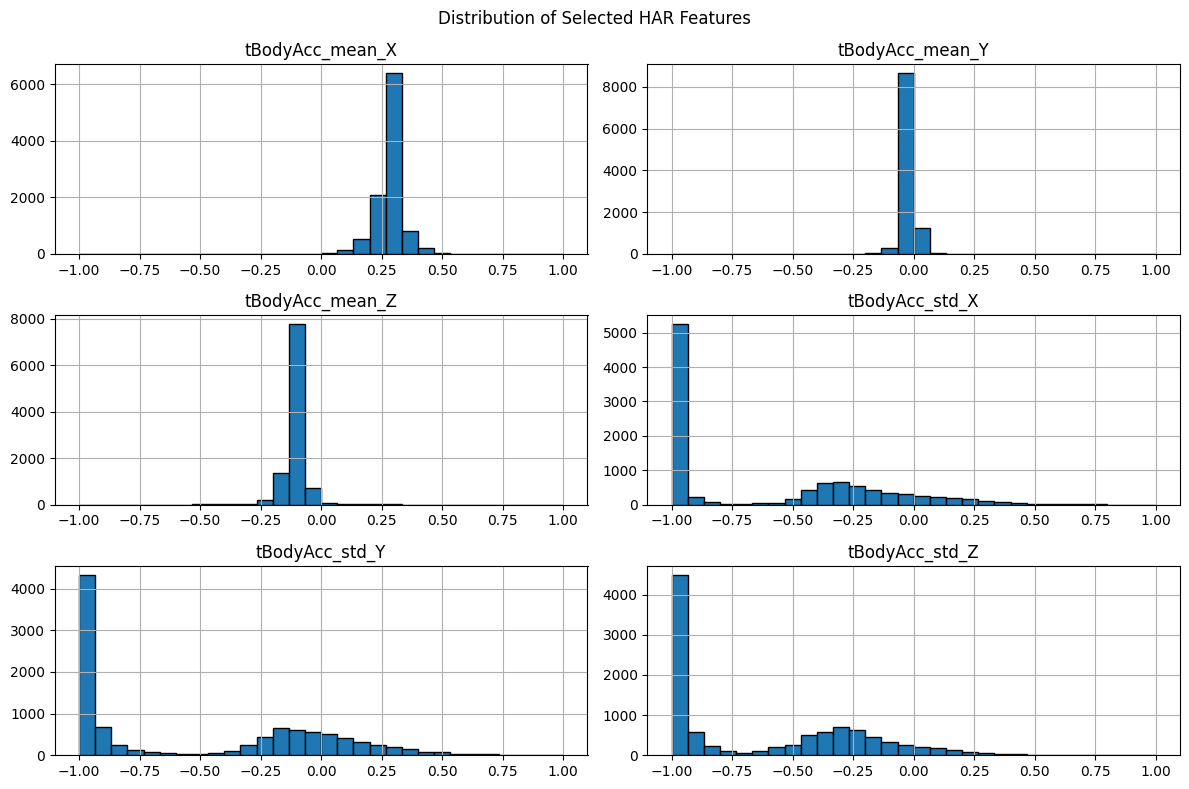

In [7]:
selected_features = X.columns[:6]

X[selected_features].hist(
    bins=30,
    figsize=(12, 8),
    edgecolor="black"
)

plt.suptitle("Distribution of Selected HAR Features")
plt.tight_layout()
plt.show()

## 6. PCA



PC1 variance: 50.74 %
PC2 variance: 6.24 %
First 2 PCs total: 56.98 %


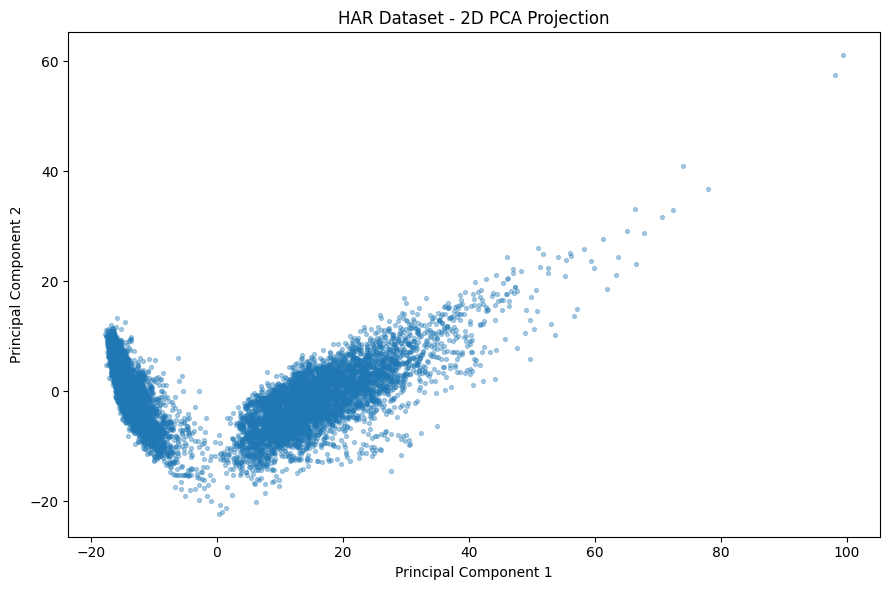

In [8]:
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print(
    "PC1 variance:",
    round(pca_2d.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "PC2 variance:",
    round(pca_2d.explained_variance_ratio_[1] * 100, 2),
    "%"
)

print(
    "First 2 PCs total:",
    round(pca_2d.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    s=8,
    alpha=0.35
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("HAR Dataset - 2D PCA Projection")
plt.tight_layout()
plt.show()

In [9]:
PCA_COMPONENTS = 30

pca_30 = PCA(
    n_components=PCA_COMPONENTS,
    random_state=RANDOM_STATE
)

X_pca = pca_30.fit_transform(X_scaled)

print("Clustering data shape:", X_pca.shape)

print(
    "Variance explained by 30 components:",
    round(
        pca_30.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

Clustering data shape: (10299, 30)
Variance explained by 30 components: 81.28 %


# Model A — K-Means Clustering


In [10]:
k_values = list(range(2, 9))

wcss = []
silhouette_values = []

for k in k_values:

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = km.fit_predict(X_pca)

    wcss.append(km.inertia_)

    silhouette_values.append(
        silhouette_score(
            X_pca,
            labels
        )
    )

kmeans_table = pd.DataFrame({
    "Number of Clusters (k)": k_values,
    "WCSS (Inertia)": wcss,
    "Silhouette Score": silhouette_values
})

display(kmeans_table.round(4))

,Number of Clusters (k),WCSS (Inertia),Silhouette Score
0,2,2.191126e+06,0.4815
1,3,1.840234e+06,0.3971
2,4,1.701285e+06,0.2157
3,5,1.575981e+06,0.1925
4,6,1.499418e+06,0.1826
5,7,1.442733e+06,0.1491
6,8,1.389404e+06,0.1428


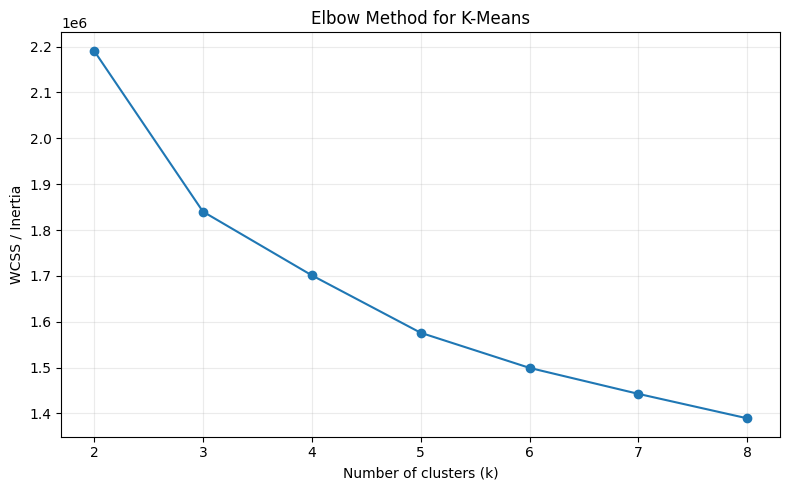

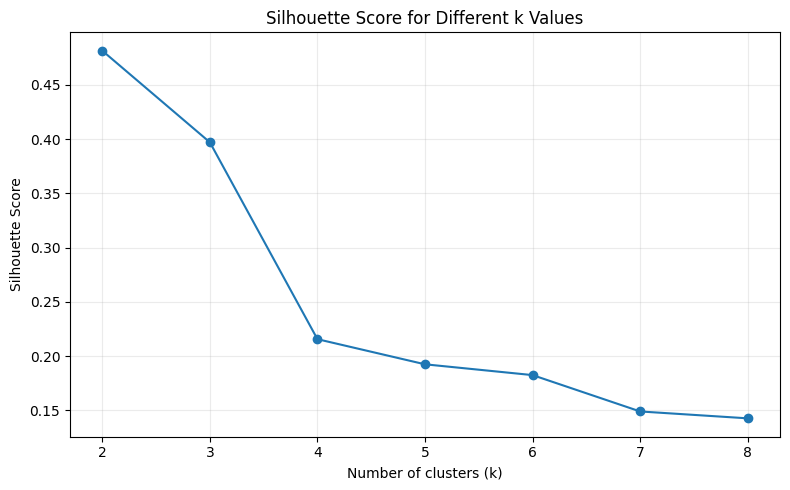

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_values,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### K-Means: selecting k



In [12]:
best_k = k_values[
    int(np.argmax(silhouette_values))
]

print("Selected k:", best_k)
print(
    "Highest silhouette score:",
    round(max(silhouette_values), 4)
)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca)

print("\nK-Means cluster sizes:")
print(
    pd.Series(kmeans_labels)
    .value_counts()
    .sort_index()
)

Selected k: 2
Highest silhouette score: 0.4815

K-Means cluster sizes:
0    5620
1    4679
Name: count, dtype: int64


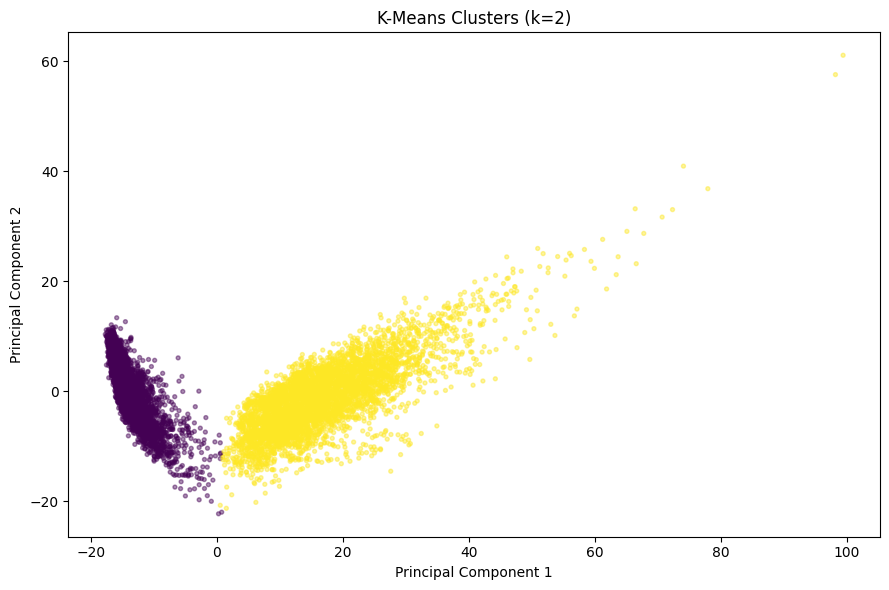

In [13]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=kmeans_labels,
    s=8,
    alpha=0.45
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"K-Means Clusters (k={best_k})")
plt.tight_layout()
plt.show()

# Model B — DBSCAN


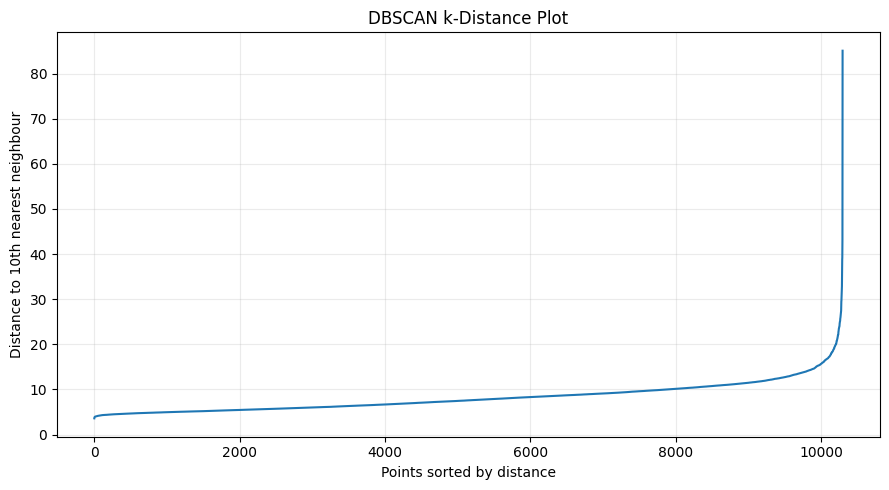

In [14]:
min_samples = 10

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_pca)

distances, indices = neighbors.kneighbors(X_pca)

k_distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(9, 5))

plt.plot(k_distances)

plt.xlabel("Points sorted by distance")
plt.ylabel(
    f"Distance to {min_samples}th nearest neighbour"
)

plt.title("DBSCAN k-Distance Plot")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [15]:
eps_candidates = [
    0.8, 1.0, 1.2, 1.4,
    1.6, 1.8, 2.0
]

dbscan_rows = []

for eps in eps_candidates:

    db = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        n_jobs=-1
    )

    labels = db.fit_predict(X_pca)

    non_noise = labels != -1
    unique_clusters = np.unique(
        labels[non_noise]
    )

    if len(unique_clusters) >= 2:
        sil = silhouette_score(
            X_pca[non_noise],
            labels[non_noise]
        )
    else:
        sil = np.nan

    dbscan_rows.append({
        "eps": eps,
        "min_samples": min_samples,
        "clusters": len(unique_clusters),
        "noise_points": int(
            np.sum(labels == -1)
        ),
        "noise_percent": round(
            100 * np.mean(labels == -1),
            2
        ),
        "silhouette_non_noise": sil
    })

dbscan_table = pd.DataFrame(
    dbscan_rows
)

display(
    dbscan_table.round(4)
)

,eps,min_samples,clusters,noise_points,noise_percent,silhouette_non_noise
0,0.8,10,0,10299,100.0,NaN
1,1.0,10,0,10299,100.0,NaN
2,1.2,10,0,10299,100.0,NaN
3,1.4,10,0,10299,100.0,NaN
4,1.6,10,0,10299,100.0,NaN
5,1.8,10,0,10299,100.0,NaN
6,2.0,10,0,10299,100.0,NaN


In [16]:
valid_dbscan = dbscan_table.dropna(
    subset=["silhouette_non_noise"]
)

if len(valid_dbscan) > 0:

    selected_eps = float(
        valid_dbscan.loc[
            valid_dbscan["silhouette_non_noise"].idxmax(),
            "eps"
        ]
    )

else:
    selected_eps = 1.4

print("Selected eps:", selected_eps)
print("min_samples:", min_samples)

dbscan = DBSCAN(
    eps=selected_eps,
    min_samples=min_samples,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_pca)

dbscan_cluster_count = len(
    set(dbscan_labels) - {-1}
)

dbscan_noise = int(
    np.sum(dbscan_labels == -1)
)

print(
    "Number of DBSCAN clusters:",
    dbscan_cluster_count
)

print(
    "Noise points:",
    dbscan_noise
)

print(
    "Noise percentage:",
    round(
        100 * dbscan_noise / len(dbscan_labels),
        2
    ),
    "%"
)

Selected eps: 1.4
min_samples: 10
Number of DBSCAN clusters: 0
Noise points: 10299
Noise percentage: 100.0 %


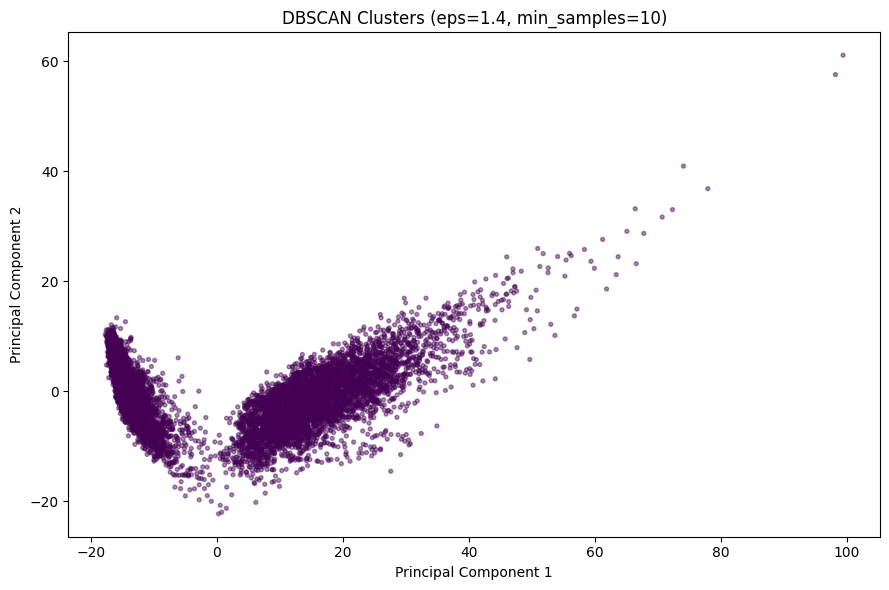

In [17]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=dbscan_labels,
    s=8,
    alpha=0.45
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    f"DBSCAN Clusters (eps={selected_eps}, "
    f"min_samples={min_samples})"
)

plt.tight_layout()
plt.show()

# Model C — Hierarchical Agglomerative Clustering


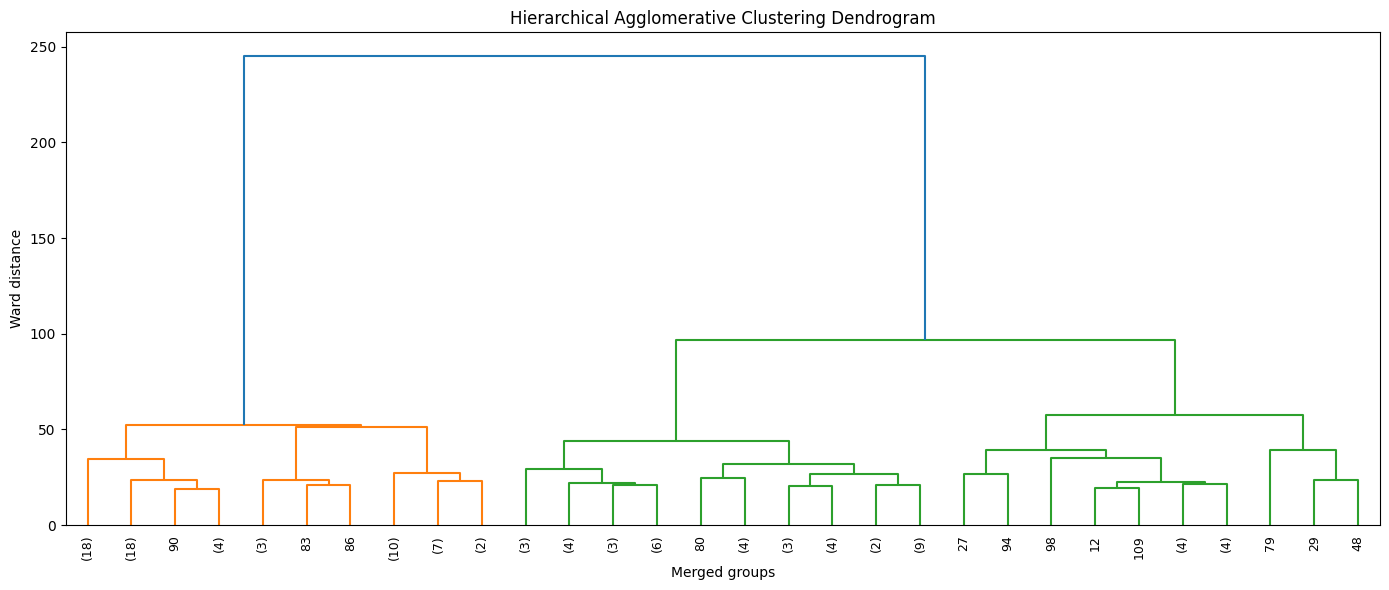

In [18]:
DENDROGRAM_SAMPLE = 120

rng = np.random.default_rng(
    RANDOM_STATE
)

sample_size = min(
    DENDROGRAM_SAMPLE,
    len(X_pca)
)

sample_indices = rng.choice(
    len(X_pca),
    size=sample_size,
    replace=False
)

X_hac_sample = X_pca[
    sample_indices
]

Z = linkage(
    X_hac_sample,
    method="ward"
)

plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.xlabel("Merged groups")
plt.ylabel("Ward distance")
plt.title(
    "Hierarchical Agglomerative Clustering Dendrogram"
)

plt.tight_layout()
plt.show()

In [19]:
hac = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hac_labels = hac.fit_predict(
    X_pca
)

print("HAC cluster sizes:")
print(
    pd.Series(hac_labels)
    .value_counts()
    .sort_index()
)

HAC cluster sizes:
0    4673
1    5626
Name: count, dtype: int64


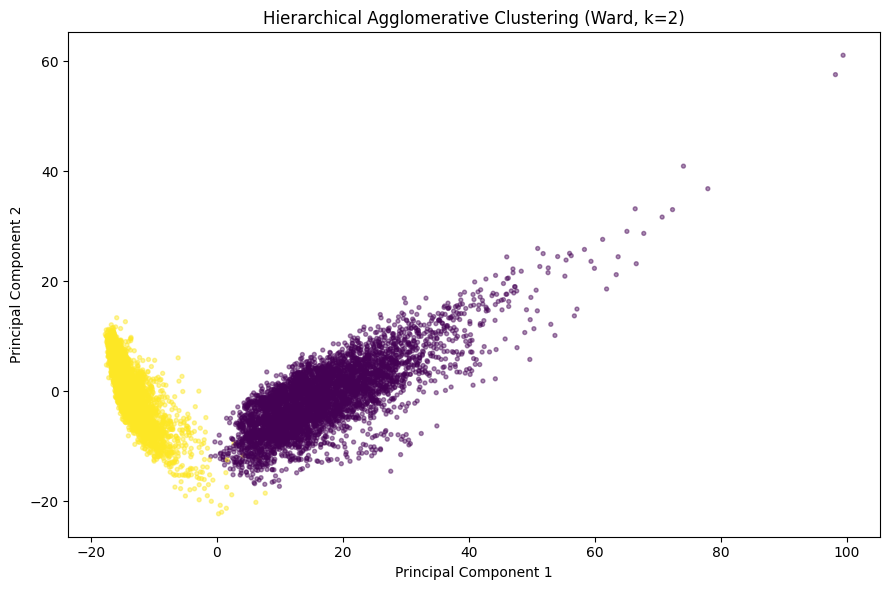

In [20]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=hac_labels,
    s=8,
    alpha=0.45
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    f"Hierarchical Agglomerative Clustering "
    f"(Ward, k={best_k})"
)

plt.tight_layout()
plt.show()

# 7. Evaluation Metrics



In [21]:
def evaluate_clustering(
    name,
    X_data,
    labels,
    true_labels
):

    labels = np.asarray(labels)

    # Ignore DBSCAN noise when calculating internal
    # cluster-quality measures.
    valid = labels != -1

    X_eval = X_data[valid]
    labels_eval = labels[valid]

    n_clusters = len(
        np.unique(labels_eval)
    )

    if (
        n_clusters >= 2
        and len(X_eval) > n_clusters
    ):

        silhouette = silhouette_score(
            X_eval,
            labels_eval
        )

        davies = davies_bouldin_score(
            X_eval,
            labels_eval
        )

        calinski = calinski_harabasz_score(
            X_eval,
            labels_eval
        )

    else:

        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    ari = adjusted_rand_score(
        true_labels,
        labels
    )

    nmi = normalized_mutual_info_score(
        true_labels,
        labels
    )

    return {
        "Algorithm": name,
        "Clusters": n_clusters,
        "Noise Points": int(
            np.sum(labels == -1)
        ),
        "Silhouette": silhouette,
        "Davies-Bouldin": davies,
        "Calinski-Harabasz": calinski,
        "ARI": ari,
        "NMI": nmi
    }


results = pd.DataFrame([
    evaluate_clustering(
        "K-Means",
        X_pca,
        kmeans_labels,
        y_true
    ),

    evaluate_clustering(
        "DBSCAN",
        X_pca,
        dbscan_labels,
        y_true
    ),

    evaluate_clustering(
        "Hierarchical (Ward)",
        X_pca,
        hac_labels,
        y_true
    )
])

display(
    results.round(4)
)

,Algorithm,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means,2,0,0.4815,0.8543,11770.8640,0.3296,0.5455
1,DBSCAN,0,10299,NaN,NaN,NaN,0.0000,0.0000
2,Hierarchical (Ward),2,0,0.4811,0.8552,11735.7909,0.3324,0.5561


# 8. Evaluation Metric Comparison

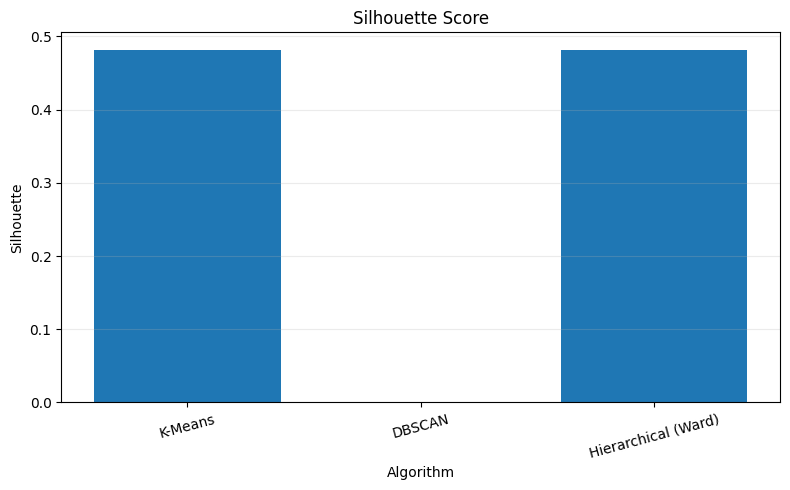

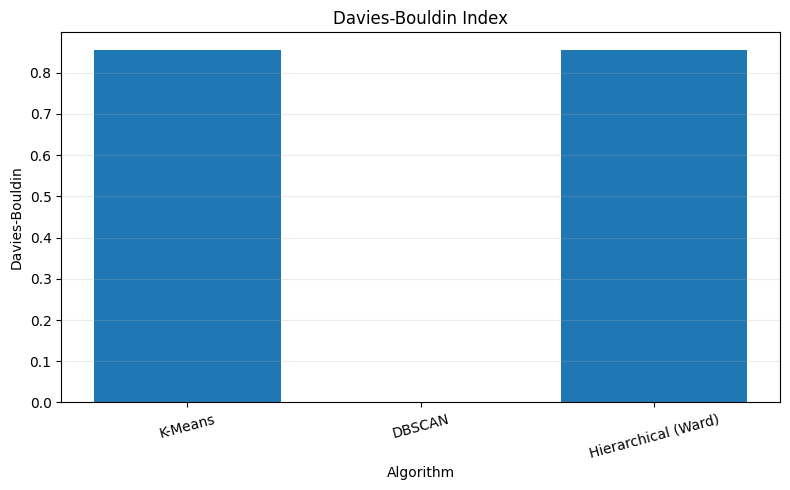

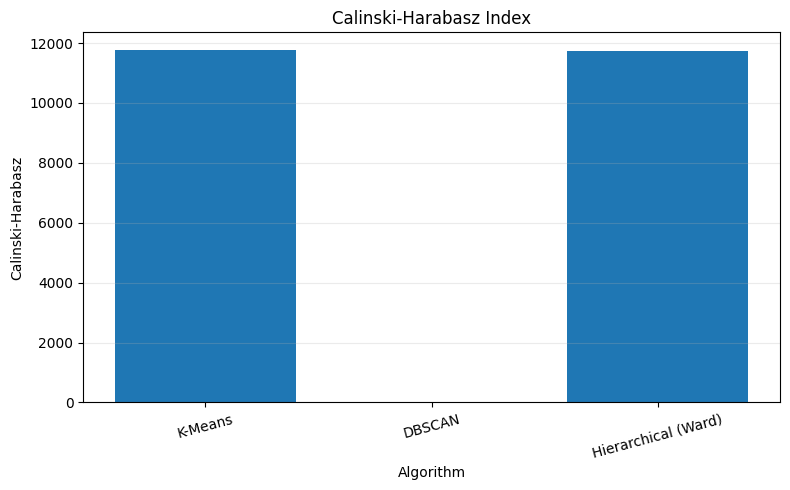

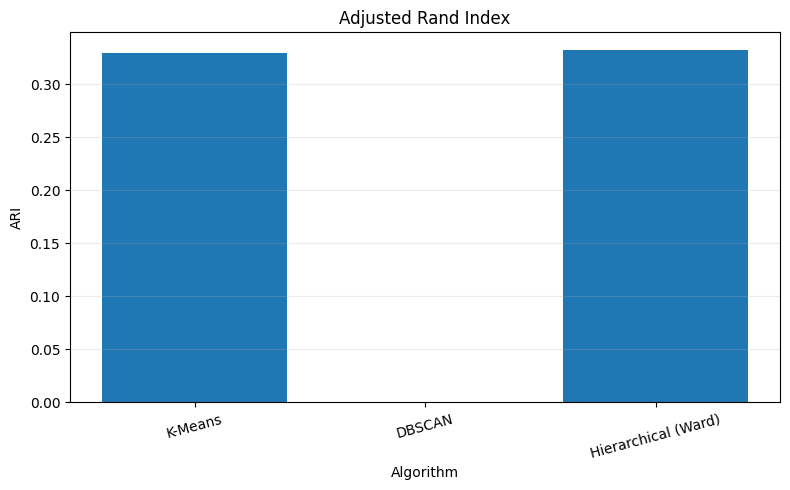

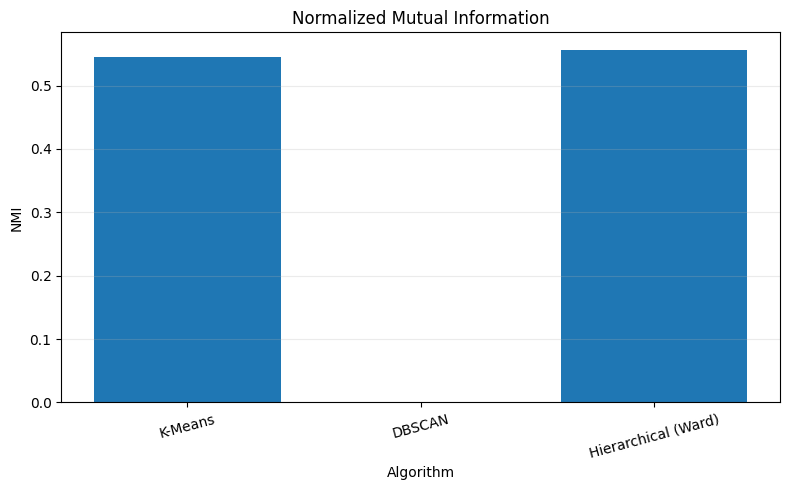

In [22]:
metric_list = [
    ("Silhouette", "Silhouette Score"),
    ("Davies-Bouldin", "Davies-Bouldin Index"),
    ("Calinski-Harabasz", "Calinski-Harabasz Index"),
    ("ARI", "Adjusted Rand Index"),
    ("NMI", "Normalized Mutual Information")
]

for column, title in metric_list:

    plt.figure(figsize=(8, 5))

    plt.bar(
        results["Algorithm"],
        results[column]
    )

    plt.xlabel("Algorithm")
    plt.ylabel(column)
    plt.title(title)
    plt.xticks(rotation=15)
    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

# 9. Cluster Size Comparison

,K-Means,DBSCAN,HAC
-1,0,10299,0
0,5620,0,4673
1,4679,0,5626


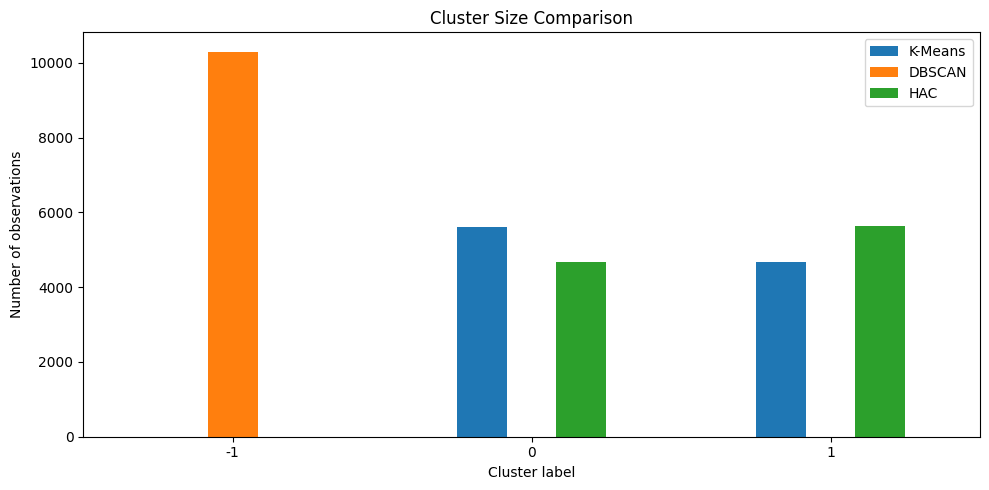

In [23]:
cluster_sizes = pd.DataFrame({
    "K-Means": pd.Series(
        kmeans_labels
    ).value_counts().sort_index(),

    "DBSCAN": pd.Series(
        dbscan_labels
    ).value_counts().sort_index(),

    "HAC": pd.Series(
        hac_labels
    ).value_counts().sort_index()
}).fillna(0).astype(int)

display(cluster_sizes)

cluster_sizes.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Cluster label")
plt.ylabel("Number of observations")
plt.title("Cluster Size Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 10. Comparison with Ground-Truth Activities



In [24]:
print("Ground-truth activity distribution:")

display(
    y["activity"]
    .value_counts()
    .reindex(
        label_encoder.classes_
    )
    .to_frame("Count")
)

def show_contingency(
    title,
    labels
):

    table = pd.crosstab(
        pd.Series(
            y["activity"],
            name="Activity"
        ),

        pd.Series(
            labels,
            name="Cluster"
        )
    )

    print("\n" + title)
    display(table)

show_contingency(
    "K-Means",
    kmeans_labels
)

show_contingency(
    "DBSCAN",
    dbscan_labels
)

show_contingency(
    "Hierarchical (Ward)",
    hac_labels
)

Ground-truth activity distribution:


,Count
activity,
LAYING,1944
SITTING,1777
STANDING,1906
WALKING,1722
WALKING_DOWNSTAIRS,1406
WALKING_UPSTAIRS,1544



K-Means


Cluster,0,1
Activity,,
LAYING,1932,12
SITTING,1774,3
STANDING,1906,0
WALKING,0,1722
WALKING_DOWNSTAIRS,0,1406
WALKING_UPSTAIRS,8,1536



DBSCAN


Cluster,-1
Activity,
LAYING,1944
SITTING,1777
STANDING,1906
WALKING,1722
WALKING_DOWNSTAIRS,1406
WALKING_UPSTAIRS,1544



Hierarchical (Ward)


Cluster,0,1
Activity,,
LAYING,0,1944
SITTING,1,1776
STANDING,0,1906
WALKING,1722,0
WALKING_DOWNSTAIRS,1406,0
WALKING_UPSTAIRS,1544,0


# 12. Final Results Table

In [25]:
final_results = results.copy()

final_results["Silhouette"] = (
    final_results["Silhouette"].round(4)
)

final_results["Davies-Bouldin"] = (
    final_results["Davies-Bouldin"].round(4)
)

final_results["Calinski-Harabasz"] = (
    final_results["Calinski-Harabasz"].round(2)
)

final_results["ARI"] = (
    final_results["ARI"].round(4)
)

final_results["NMI"] = (
    final_results["NMI"].round(4)
)

display(final_results)

,Algorithm,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means,2,0,0.4815,0.8543,11770.86,0.3296,0.5455
1,DBSCAN,0,10299,NaN,NaN,NaN,0.0000,0.0000
2,Hierarchical (Ward),2,0,0.4811,0.8552,11735.79,0.3324,0.5561
